# LGBM

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.model_selection import TimeSeriesSplit


In [2]:
DATA_PATH = Path("../data/features/ptf_features.parquet")

df = pd.read_parquet(DATA_PATH)
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"],errors="coerce")
    df = df.dropna(subset=["date"])
    df = df.set_index("date")
df =df.sort_index()

print("Shape:",df.shape)
df.head()


Shape: (71304, 18)


,ptf,hour,day_of_week,dow_sin,dow_cos,is_weekend,hour_sin,hour_cos,lag_1,lag_24,lag_168,lag_336,rolling_mean_24,rolling_mean_168,diff_1,diff_24,diff_168,target
date,,,,,,,,,,,,,,,,,,
2018-01-15 00:00:00,193.13,0,0,0.0,1.0,0,0.000000,1.000000,174.00,179.81,173.74,207.60,178.616667,184.406607,-13.99,-9.40,10.77,189.40
2018-01-15 01:00:00,193.12,1,0,0.0,1.0,0,0.258819,0.965926,193.13,180.00,169.99,205.34,179.171667,184.522024,19.13,13.32,19.39,178.99
2018-01-15 02:00:00,125.01,2,0,0.0,1.0,0,0.500000,0.866025,193.12,159.99,135.00,164.94,179.718333,184.659702,-0.01,13.12,23.13,169.07
2018-01-15 03:00:00,125.01,3,0,0.0,1.0,0,0.707107,0.707107,125.01,185.00,134.99,154.52,178.260833,184.600238,-68.11,-34.98,-9.99,170.00
2018-01-15 04:00:00,125.01,4,0,0.0,1.0,0,0.866025,0.500000,125.01,160.00,134.99,112.64,175.761250,184.540833,0.00,-59.99,-9.98,160.00


In [3]:
print(df.columns.tolist())

['ptf', 'hour', 'day_of_week', 'dow_sin', 'dow_cos', 'is_weekend', 'hour_sin', 'hour_cos', 'lag_1', 'lag_24', 'lag_168', 'lag_336', 'rolling_mean_24', 'rolling_mean_168', 'diff_1', 'diff_24', 'diff_168', 'target']


In [4]:
TARGET_COL ="target"
X =df.drop(columns=[TARGET_COL]).copy()
y=df[TARGET_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (71304, 17)
y shape: (71304,)


In [5]:
n = len(df)

train_end = int(n*0.70)
val_end = int(n*0.85)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val =X.iloc[train_end:val_end].copy()
y_val =y.iloc[train_end:val_end].copy()

X_test = X.iloc[val_end :].copy()
y_test = y.iloc[val_end :].copy()


print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

print("Train start:", X_train.index.min(), "| Train end:", X_train.index.max())
print("Val start  :", X_val.index.min(), "| Val end  :", X_val.index.max())
print("Test start :", X_test.index.min(), "| Test end :", X_test.index.max())

Train: (49912, 17) (49912,)
Val  : (10696, 17) (10696,)
Test : (10696, 17) (10696,)
Train start: 2018-01-15 00:00:00 | Train end: 2023-09-25 15:00:00
Val start  : 2023-09-25 16:00:00 | Val end  : 2024-12-14 07:00:00
Test start : 2024-12-14 08:00:00 | Test end : 2026-03-04 23:00:00


In [6]:
def mean_absolute_error_percentage_error_safe(y_true,y_pred):
    y_true = np.array(y_true)
    y_pred =y_pred

    mask = y_true != 0
    if mask.sum() ==0:
        return np.nan
    
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_forecast(y_true,y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mape = mean_absolute_error_percentage_error_safe(y_true,y_pred)

    return {
        "MAE" : mae,
        "RMSE" : rmse,
        "MAPE" : mape
    }

In [8]:
baseline_pred = X_test["lag_24"].copy()
baseline_metrics =evaluate_forecast(y_test,baseline_pred)
baseline_metrics

{'MAE': 495.437054973822,
 'RMSE': np.float64(790.8298581674015),
 'MAPE': np.float64(302.042392094482)}

In [10]:
initial_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth = 6,
    num_leaves =31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose = -1
)

initial_model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
val_pred_initial = initial_model.predict(X_val)
val_metrics_initial =evaluate_forecast(y_val,val_pred_initial)

val_metrics_initial

{'MAE': 298.19177449784644,
 'RMSE': np.float64(410.9778310665475),
 'MAPE': np.float64(70.30348993788792)}

In [12]:
test_pred_initial = initial_model.predict(X_test)

test_metrics_initial = evaluate_forecast(y_test,test_pred_initial)
test_metrics_initial

{'MAE': 385.4400177659906,
 'RMSE': np.float64(543.7606524323262),
 'MAPE': np.float64(248.15063099805377)}

In [13]:
comparison_initial = pd.DataFrame([
    {
        "Model": "Baseline_lag24",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "MAPE": baseline_metrics["MAPE"],
    },
    {
        "Model": "LGBM_initial",
        "MAE": test_metrics_initial["MAE"],
        "RMSE": test_metrics_initial["RMSE"],
        "MAPE": test_metrics_initial["MAPE"],
    }
])

comparison_initial

,Model,MAE,RMSE,MAPE
0,Baseline_lag24,495.437055,790.829858,302.042392
1,LGBM_initial,385.440018,543.760652,248.150631


In [15]:
plot_df = pd.DataFrame({
    "actual": y_test,
    "baseline_lag24": baseline_pred,
    "lgbm_initial": test_pred_initial,
}, index=y_test.index)

plot_df = plot_df.dropna().iloc[:24 * 14]
plot_df.head()

,actual,baseline_lag24,lgbm_initial
date,,,
2024-12-14 08:00:00,1650.0,3000.00,2105.708767
2024-12-14 09:00:00,1425.0,3000.00,2090.402402
2024-12-14 10:00:00,1050.0,2949.99,1810.923546
2024-12-14 11:00:00,1300.0,2689.00,1520.112652
2024-12-14 12:00:00,1050.0,1983.99,1375.776754


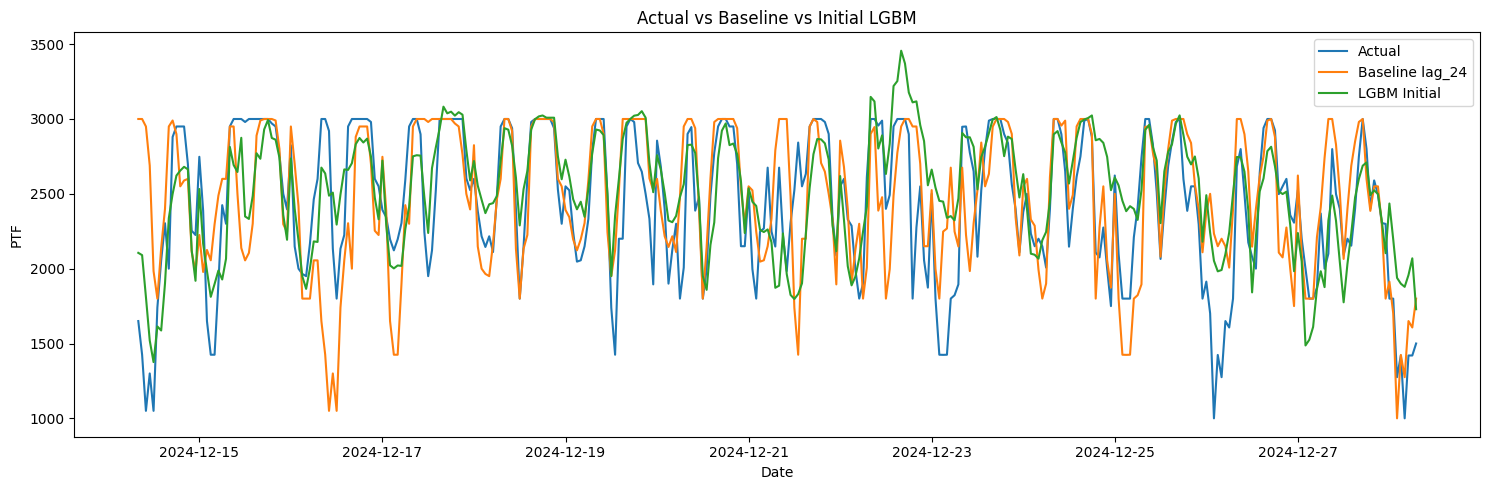

In [16]:
plt.figure(figsize=(15, 5))
plt.plot(plot_df.index, plot_df["actual"], label="Actual")
plt.plot(plot_df.index, plot_df["baseline_lag24"], label="Baseline lag_24")
plt.plot(plot_df.index, plot_df["lgbm_initial"], label="LGBM Initial")
plt.title("Actual vs Baseline vs Initial LGBM")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
X_dev = pd.concat([X_train,X_val],axis=0)
y_dev =pd.concat([y_train,y_val],axis =0)

print("X_dev:",X_dev.shape)
print("Y_dev:",y_dev.shape)

X_dev: (60608, 17)
Y_dev: (60608,)


In [23]:
tscv = TimeSeriesSplit(n_splits=3)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    print(f"Fold {fold}")
    print("Train size:", len(train_idx))
    print("Val size  :", len(val_idx))
    print("-" * 30)


Fold 1
Train size: 15152
Val size  : 15152
------------------------------
Fold 2
Train size: 30304
Val size  : 15152
------------------------------
Fold 3
Train size: 45456
Val size  : 15152
------------------------------


In [29]:
param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.02, 0.03, 0.04],
    "max_depth": [4, 6],
    "num_leaves": [15, 31, 50]
}

total_models = (
    len(param_grid["n_estimators"]) *
    len(param_grid["learning_rate"]) *
    len(param_grid["max_depth"]) *
    len(param_grid["num_leaves"])
)



print("Parameter combinations:", total_models)
print("Total fits with CV    :", total_models * 3)


Parameter combinations: 72
Total fits with CV    : 216


In [30]:
results = []

for n_estimators, learning_rate, max_depth, num_leaves in product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["max_depth"],
    param_grid["num_leaves"],
):
    fold_mae = []
    fold_rmse = []
    fold_mape = []

    for train_idx, val_idx in tscv.split(X_dev):
        X_tr = X_dev.iloc[train_idx]
        y_tr = y_dev.iloc[train_idx]

        X_va = X_dev.iloc[val_idx]
        y_va = y_dev.iloc[val_idx]

        model = LGBMRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            num_leaves=num_leaves,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_tr, y_tr)

        val_pred = model.predict(X_va)
        metrics = evaluate_forecast(y_va, val_pred)

        fold_mae.append(metrics["MAE"])
        fold_rmse.append(metrics["RMSE"])
        fold_mape.append(metrics["MAPE"])

    result_row = {
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "num_leaves": num_leaves,
        "CV_MAE": np.mean(fold_mae),
        "CV_RMSE": np.mean(fold_rmse),
        "CV_MAPE": np.mean(fold_mape),
    }

    results.append(result_row)

    print(
        f"Done | n_estimators={n_estimators}, "
        f"learning_rate={learning_rate}, "
        f"max_depth={max_depth}, "
        f"num_leaves={num_leaves}, "
        f"CV_MAE={result_row['CV_MAE']:.2f}"
    )

Done | n_estimators=300, learning_rate=0.02, max_depth=4, num_leaves=15, CV_MAE=608.08
Done | n_estimators=300, learning_rate=0.02, max_depth=4, num_leaves=31, CV_MAE=608.25
Done | n_estimators=300, learning_rate=0.02, max_depth=4, num_leaves=50, CV_MAE=608.25
Done | n_estimators=300, learning_rate=0.02, max_depth=6, num_leaves=15, CV_MAE=605.88
Done | n_estimators=300, learning_rate=0.02, max_depth=6, num_leaves=31, CV_MAE=602.86
Done | n_estimators=300, learning_rate=0.02, max_depth=6, num_leaves=50, CV_MAE=605.40
Done | n_estimators=300, learning_rate=0.03, max_depth=4, num_leaves=15, CV_MAE=605.24
Done | n_estimators=300, learning_rate=0.03, max_depth=4, num_leaves=31, CV_MAE=604.58
Done | n_estimators=300, learning_rate=0.03, max_depth=4, num_leaves=50, CV_MAE=604.58
Done | n_estimators=300, learning_rate=0.03, max_depth=6, num_leaves=15, CV_MAE=603.07
Done | n_estimators=300, learning_rate=0.03, max_depth=6, num_leaves=31, CV_MAE=601.41
Done | n_estimators=300, learning_rate=0.03

In [31]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("CV_MAE").reset_index(drop=True)

results_df.head(10)

,n_estimators,learning_rate,max_depth,num_leaves,CV_MAE,CV_RMSE,CV_MAPE
0,500,0.02,6,31,600.721919,798.936252,194.967421
1,300,0.03,6,31,601.414523,799.632097,191.584987
2,500,0.02,6,15,601.631682,798.808546,194.606244
3,300,0.04,6,31,601.853357,800.083850,191.355074
4,800,0.03,6,15,601.976586,799.794919,189.731046
5,1000,0.02,6,15,602.007071,799.681589,190.952761
6,800,0.02,6,15,602.062656,799.463450,191.793269
7,300,0.04,6,15,602.073309,799.303793,193.959226
8,500,0.03,6,31,602.154101,800.308341,192.625175
9,500,0.03,6,15,602.266746,799.396471,192.884018


In [33]:
best_params = results_df.iloc[0].to_dict()
best_params

{'n_estimators': 500.0,
 'learning_rate': 0.02,
 'max_depth': 6.0,
 'num_leaves': 31.0,
 'CV_MAE': 600.7219189624012,
 'CV_RMSE': 798.9362523462029,
 'CV_MAPE': 194.96742109215037}

In [34]:
best_model= LGBMRegressor(
    n_estimators=int(best_params["n_estimators"]),
    learning_rate=float(best_params["learning_rate"]),
    max_depth=int(best_params["max_depth"]),
    num_leaves=int(best_params["num_leaves"]),
    subsample =0.8,
    colsample_bytree=0.8,
    random_state=42
)

best_model.fit(X_dev,y_dev)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.02
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [35]:
best_test_pred = best_model.predict(X_test)

best_test_metrics =evaluate_forecast(y_test,best_test_pred)
best_test_metrics

{'MAE': 349.76137139658175,
 'RMSE': np.float64(497.77141351421676),
 'MAPE': np.float64(162.8586592870206)}

In [36]:
final_comparison = pd.DataFrame([
    {
        "Model": "Baseline_lag24",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "MAPE": baseline_metrics["MAPE"],
    },
    {
        "Model": "Best_LGBM",
        "MAE": best_test_metrics["MAE"],
        "RMSE": best_test_metrics["RMSE"],
        "MAPE": best_test_metrics["MAPE"],
    }
])

final_comparison

,Model,MAE,RMSE,MAPE
0,Baseline_lag24,495.437055,790.829858,302.042392
1,Best_LGBM,349.761371,497.771414,162.858659


In [39]:
plot_df_final = pd.DataFrame({
    "actual": y_test,
    "baseline_lag24": baseline_pred,
    "best_lgbm_pred": best_test_pred,
}, index=y_test.index)

plot_df_final = plot_df_final.dropna().iloc[:24 * 14]
plot_df_final.head()

,actual,baseline_lag24,best_lgbm_pred
date,,,
2024-12-14 08:00:00,1650.0,3000.00,2073.855370
2024-12-14 09:00:00,1425.0,3000.00,2122.850658
2024-12-14 10:00:00,1050.0,2949.99,1854.162628
2024-12-14 11:00:00,1300.0,2689.00,1458.822489
2024-12-14 12:00:00,1050.0,1983.99,1137.534806


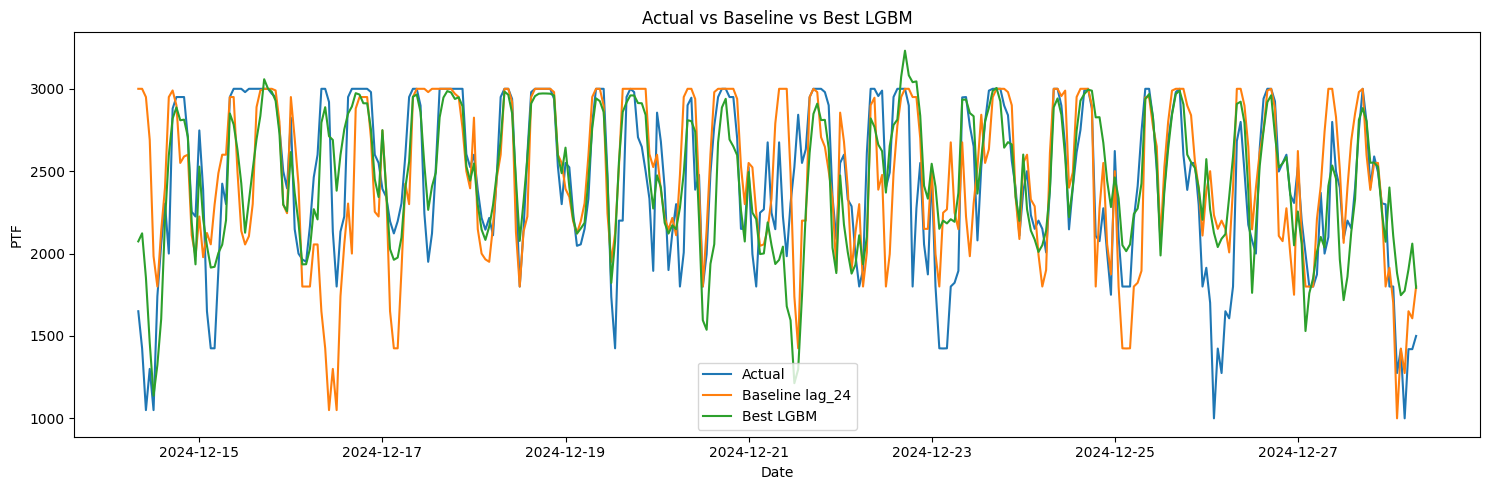

In [40]:
plt.figure(figsize=(15, 5))
plt.plot(plot_df_final.index, plot_df_final["actual"], label="Actual")
plt.plot(plot_df_final.index, plot_df_final["baseline_lag24"], label="Baseline lag_24")
plt.plot(plot_df_final.index, plot_df_final["best_lgbm_pred"], label="Best LGBM")
plt.title("Actual vs Baseline vs Best LGBM")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
importance_df = pd.DataFrame({
    "feature" : X_dev.columns,
    "importance" : best_model.feature_importances_
}).sort_values("importance",ascending=False).reset_index(drop=True)

importance_df.head(15)

,index,feature,importance
0,13,rolling_mean_168,2182
1,12,rolling_mean_24,1361
2,0,ptf,1342
3,9,lag_24,1077
4,11,lag_336,966
5,2,day_of_week,955
6,10,lag_168,920
7,1,hour,892
8,7,hour_cos,883
9,15,diff_24,814


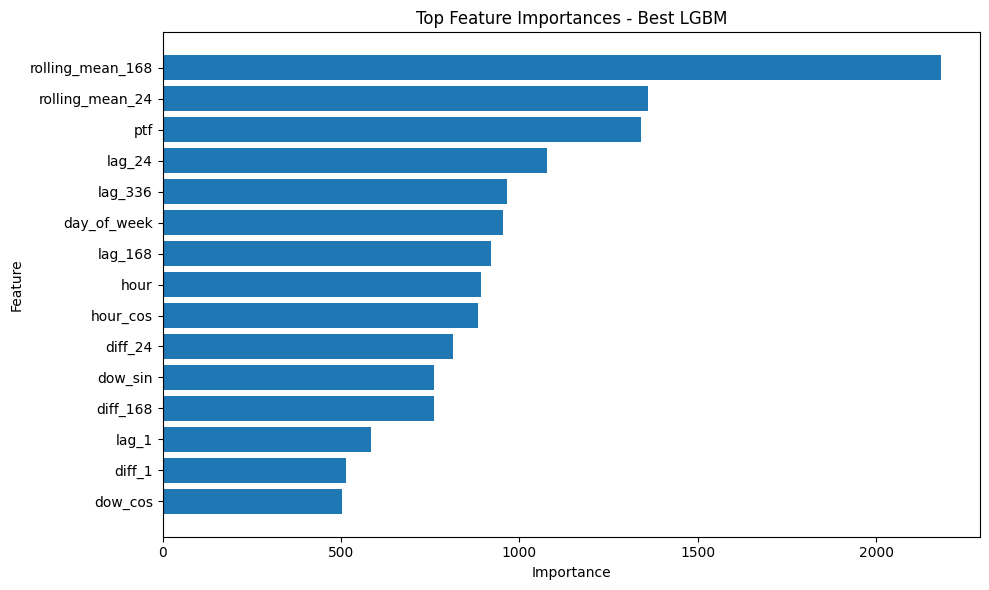

In [44]:
top_n = 15
plot_importance_df = importance_df.head(top_n).sort_values("importance",ascending =True)

plt.figure(figsize=(10, 6))
plt.barh(plot_importance_df["feature"], plot_importance_df["importance"])
plt.title("Top Feature Importances - Best LGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


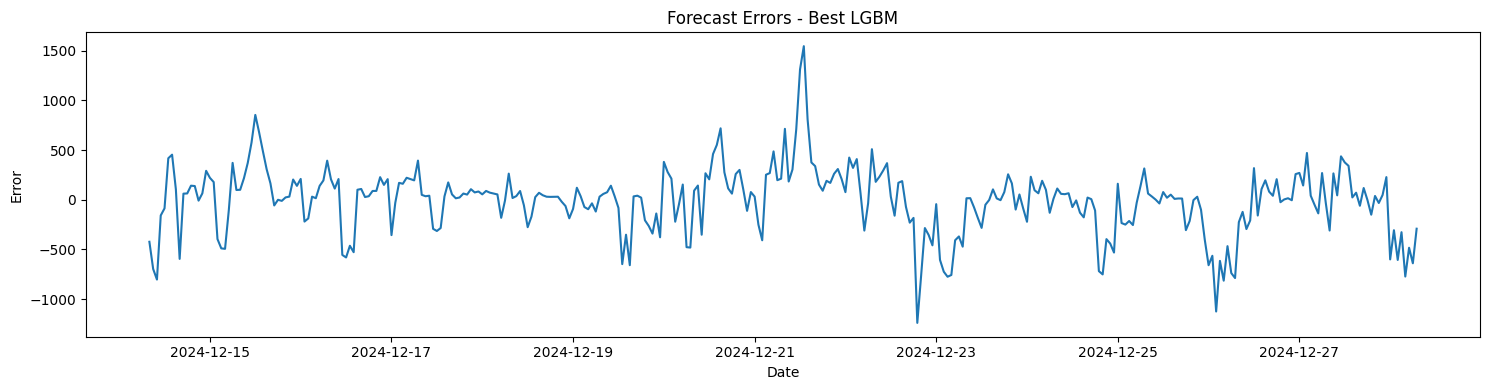

In [45]:
errors = y_test - best_test_pred

plt.figure(figsize=(15, 4))
plt.plot(y_test.index[:24 * 14], errors[:24 * 14])
plt.title("Forecast Errors - Best LGBM")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook, a LightGBM model was trained for PTF forecasting.

The following steps were performed:

- loading the feature table
- comparing results with a lag-24 baseline
- running an initial model experiment
- performing cross-validation using TimeSeriesSplit
- selecting hyperparameters through a small grid search
- evaluating the final model on the test set
- analyzing feature importance

In the next step, the best-performing model can be integrated into a production forecasting script.